In [ ]:
import warnings
warnings.filterwarnings("ignore") # Faltu ki warnings ko chup karaya

from transformers import OneFormerProcessor, OneFormerForUniversalSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt

In [ ]:
#!pip install -q natten

In [ ]:
def run_segmentation(image, task_type):
    """Performs image segmentation based on the given task type.

    Args:
        image (PIL.Image): The input image.
        task_type (str): The type of segmentation to perform ('semantic', 'instance', or 'panoptic').

    Returns:
        PIL.Image: The segmented image.

    Raises:
        ValueError: If the task type is invalid.
    """

# CHANGE 1: Use the Swin Transformer version (No natten required)
    #model_name = "shi-labs/oneformer_ade20k_swin_large"

    # Alternatively, use a smaller version if 'large' is too slow:
    model_name = "shi-labs/oneformer_ade20k_swin_tiny"

    processor = OneFormerProcessor.from_pretrained(model_name)
    model = OneFormerForUniversalSegmentation.from_pretrained(model_name)
    if task_type == "semantic":
        inputs = processor(images=image, task_inputs=["semantic"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_semantic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]

    elif task_type == "instance":
        inputs = processor(images=image, task_inputs=["instance"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_instance_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]["segmentation"]

    elif task_type == "panoptic":
        inputs = processor(images=image, task_inputs=["panoptic"], return_tensors="pt")
        outputs = model(**inputs)
        predicted_map = processor.post_process_panoptic_segmentation(
            outputs, target_sizes=[image.size[::-1]]
        )[0]["segmentation"]

    else:
        raise ValueError(
            "Invalid task type. Choose from 'semantic', 'instance', or 'panoptic'"
        )

    return predicted_map

In [ ]:
def show_image_comparison(image, predicted_map, segmentation_title):
    """Displays the original image and the segmented image side-by-side.

    Args:
        image (PIL.Image): The original image.
        predicted_map (PIL.Image): The segmented image.
        segmentation_title (str): The title for the segmented image.
    """

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(predicted_map)
    plt.title(segmentation_title + " Segmentation")
    plt.axis("off")
    plt.show()

In [ ]:
url = "https://huggingface.co/datasets/shi-labs/oneformer_demo/resolve/main/ade20k.jpeg"
response = requests.get(url, stream=True)
response.raise_for_status()  # Check for HTTP errors
image = Image.open(response.raw)

`label_ids_to_fuse` unset. No instance will be fused.


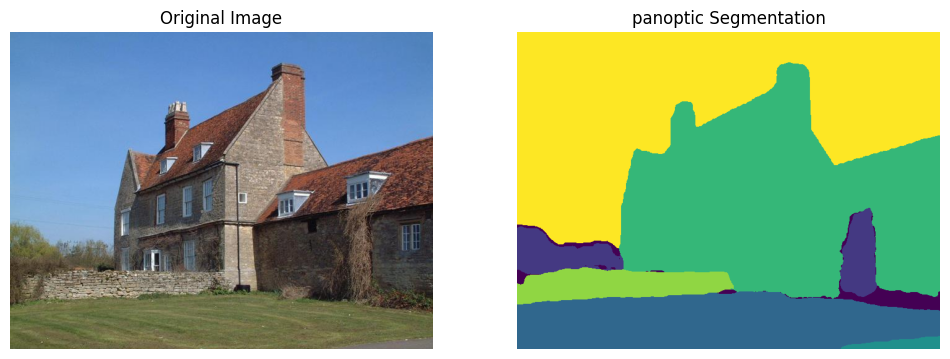

In [ ]:


task_to_run = "panoptic"
predicted_map = run_segmentation(image, task_to_run)
show_image_comparison(image, predicted_map, task_to_run)